# Import thư viện, mount Google Drive, đọc dữ liệu

In [72]:
import numpy as np
import pandas as pd
import random
import warnings

import lightgbm as lgb
import matplotlib.pyplot as plt
import seaborn as sns

import xgboost as xgb

from sklearn.linear_model import SGDClassifier
from sklearn.neighbors import BallTree
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
from sklearn.metrics.pairwise import cosine_similarity, pairwise_distances
from sklearn.preprocessing import MultiLabelBinarizer, StandardScaler
from sklearn.utils.class_weight import compute_class_weight

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print("✅ Import & mount hoàn tất.")

PATH = '/content/drive/MyDrive/Intro to AI/Final_Data/foursquare_super_final_features.csv'
df_raw = pd.read_csv(PATH)

# Chỉ cần parse timestamp — mọi cột feature đã có sẵn và chuẩn hoá
df_raw['utcTimestamp'] = pd.to_datetime(df_raw['utcTimestamp'], errors='coerce')
if df_raw['utcTimestamp'].dt.tz is not None:
    df_raw['utcTimestamp'] = df_raw['utcTimestamp'].dt.tz_localize(None)

df_raw['userId']           = df_raw['userId'].astype(int)
df_raw['parent_category']  = df_raw['parent_category'].astype(str)
df_raw['simulated_rating'] = pd.to_numeric(df_raw['simulated_rating'], errors='coerce').fillna(3.0)
df_raw = df_raw.dropna(subset=['latitude', 'longitude', 'utcTimestamp'])
df_raw = df_raw.sort_values(['userId', 'utcTimestamp']).reset_index(drop=True)

print(f"✅ Dữ liệu đã load: {df_raw.shape}")
print(f"   Users: {df_raw['userId'].nunique():,} | Check-ins: {len(df_raw):,} | Clusters: {df_raw['cluster'].nunique()}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Import & mount hoàn tất.
✅ Dữ liệu đã load: (197150, 26)
   Users: 1,031 | Check-ins: 197,150 | Clusters: 6


# Hàm dùng chung

In [73]:
# 1. Haversine
def haversine_vectorized(lat1, lon1, lat2_arr, lon2_arr):
    R = 6371.0
    dlat = np.radians(lat2_arr - lat1)
    dlon = np.radians(lon2_arr - lon1)
    a = (np.sin(dlat / 2) ** 2
         + np.cos(np.radians(lat1)) * np.cos(np.radians(lat2_arr))
         * np.sin(dlon / 2) ** 2)
    return 2 * R * np.arcsin(np.sqrt(np.clip(a, 0, 1)))


# 2. BallTree theo toạ độ (Tính năng 1)
def build_spatial_index_by_coord(df):
    # Nhóm theo placeId để giữ nguyên vẹn cặp thông tin chuẩn của Địa điểm đó
    places_df = (
        df.groupby('placeId')
        .agg(
            latitude=('latitude', 'first'),
            longitude=('longitude', 'first'),
            venueCategory=('venueCategory', 'first'),
            parent_category=('parent_category', 'first')
        )
        .reset_index()
    )
    tree = BallTree(np.radians(places_df[['latitude', 'longitude']].values), metric='haversine')
    return tree, places_df


# 3. BallTree theo placeId (Tính năng 2 & 3)
def build_spatial_index_by_place(df):
    places_df = (
        df.groupby('placeId')
        .agg(latitude=('latitude', 'first'), longitude=('longitude', 'first'),
             venueCategory=('venueCategory', 'first'),
             parent_category=('parent_category', 'first'))
        .reset_index()
    )
    tree = BallTree(np.radians(places_df[['latitude', 'longitude']].values), metric='haversine')
    return tree, places_df


# 4. Profile matrix — dùng cluster sẵn có trong dataset (Tính năng 2 & 3)
def build_profile_matrix(df):
    """Pivot rating theo user x category. Đọc cluster trực tiếp từ cột 'cluster'."""
    matrix = df.pivot_table(
        index='userId', columns='parent_category',
        values='simulated_rating', aggfunc='mean'
    ).fillna(0)
    cluster_labels = df.groupby('userId')['cluster'].first()
    print(f"  ✓ Profile matrix: {matrix.shape} | "
          f"{cluster_labels.nunique()} clusters | {cluster_labels.value_counts().to_dict()}")
    return matrix, cluster_labels


print("✅ Shared utilities đã định nghĩa.")

✅ Shared utilities đã định nghĩa.


# Các tính năng

## Tính năng 1: Gợi ý theo lịch sử

In [74]:
# =====================================================================
# 1. KHỞI TẠO CHỈ MỤC KHÔNG GIAN
# =====================================================================
def build_spatial_index_by_coord(df):
    places_df = (
        df.groupby(['latitude', 'longitude'])
        .agg(
            placeId=('placeId', 'first'),
            venueCategory=('venueCategory', 'first'),
            parent_category=('parent_category', 'first')
        )
        .reset_index()
    )
    tree = BallTree(np.radians(places_df[['latitude', 'longitude']].values), metric='haversine')
    return tree, places_df


# =====================================================================
# 2. LOGIC PROFILE & COLLABORATIVE
# =====================================================================
def _build_user_profiles_t1(train_df):
    profiles = {}
    for uid, grp in train_df.groupby('userId'):
        cat_counts  = grp['parent_category'].value_counts()
        hour_counts = grp['hour'].value_counts()
        row = grp[['user_home_lat', 'user_home_lon', 'user_mobility_radius']].dropna().head(1)
        profiles[uid] = {
            'fav_category':    cat_counts.index[0] if not cat_counts.empty else '',
            'cat_freq':        cat_counts.to_dict(),
            'hour_freq':       hour_counts.to_dict(),
            'total_checkins':  len(grp),
            'home_lat':        row.iloc[0]['user_home_lat']         if not row.empty else None,
            'home_lon':        row.iloc[0]['user_home_lon']         if not row.empty else None,
            'mobility_radius': row.iloc[0]['user_mobility_radius']  if not row.empty else 5.0,
        }
    return profiles


def _update_profile_online_t1(profile, row):
    cat  = row['parent_category']
    hour = int(row['hour'])
    profile['cat_freq'][cat]   = profile['cat_freq'].get(cat, 0) + 1
    profile['hour_freq'][hour] = profile['hour_freq'].get(hour, 0) + 1
    profile['total_checkins'] += 1
    profile['fav_category']    = max(profile['cat_freq'], key=profile['cat_freq'].get)


def _precompute_jaccard_t1(train_df, top_n=5):
    from sklearn.metrics import pairwise_distances
    user_cats = train_df.groupby('userId')['parent_category'].apply(list).to_dict()
    user_ids  = list(user_cats.keys())
    if not user_ids: return {}
    mlb  = MultiLabelBinarizer(sparse_output=True)
    mat  = mlb.fit_transform([user_cats[uid] for uid in user_ids])
    sim  = 1 - pairwise_distances(mat.toarray().astype(bool), metric='jaccard', n_jobs=-1)
    out = {}
    for idx, uid in enumerate(user_ids):
        top = [i for i in np.argsort(sim[idx])[::-1] if user_ids[i] != uid][:top_n]
        out[uid] = [user_ids[i] for i in top]
    return out


# =====================================================================
# 3. FEATURE ENGINEERING CAO CẤP
# =====================================================================
def _build_features_t1(u_lat, u_lon, current_hour,
                       h_sin, h_cos, day_sin, day_cos, is_weekend,
                       uid, candidates, user_profiles, places_df):
    p   = user_profiles.get(uid, {})
    fav = p.get('fav_category', '')
    cf  = p.get('cat_freq', {})
    hf  = p.get('hour_freq', {})
    tot = max(p.get('total_checkins', 1), 1)
    mhf = max(hf.values(), default=1)
    hlat = p.get('home_lat', u_lat); hlon = p.get('home_lon', u_lon)
    mob  = max(p.get('mobility_radius', 5.0), 0.1)
    n    = len(candidates)

    lats = np.array([c['latitude']  for c in candidates])
    lons = np.array([c['longitude'] for c in candidates])
    pops = np.array([c.get('popularity', 1) for c in candidates], dtype=float)

    dists   = haversine_vectorized(u_lat, u_lon, lats, lons)
    hdists  = haversine_vectorized(hlat,  hlon,  lats, lons)
    pop_max = pops.max() if pops.max() > 0 else 1.0

    dist_ranks = np.argsort(np.argsort(dists)).astype(float)

    geo_sim      = np.exp(-(dists / 0.8) ** 2)
    geo_mob_sim  = np.exp(-(dists / mob) ** 2)
    inv_dist     = 1.0 / (dists + 0.1)

    is_fav       = np.array([1.0 if c['parent_category'] == fav else 0.0 for c in candidates])
    cat_pref     = np.array([cf.get(c['parent_category'], 0) / tot for c in candidates])
    hour_pref    = np.full(n, hf.get(current_hour, 0) / mhf)
    norm_pop     = pops / pop_max
    home_sim     = np.exp(-hdists / 10.0)

    is_meal_time = 1.0 if current_hour in [11, 12, 13, 18, 19, 20] else 0.0
    is_night_life = 1.0 if current_hour >= 21 or current_hour <= 3 else 0.0

    is_meal_arr = np.full(n, is_meal_time)
    is_night_arr = np.full(n, is_night_life)

    geo_x_cat     = geo_sim * cat_pref
    geo_x_fav     = geo_sim * is_fav
    inv_dist_x_cat = inv_dist * cat_pref
    hour_x_cat    = hour_pref * cat_pref
    meal_x_cat    = is_meal_arr * cat_pref
    night_x_cat   = is_night_arr * cat_pref
    is_weekend_arr = np.full(n, float(is_weekend))

    return np.column_stack([
        geo_sim,
        geo_mob_sim,
        inv_dist,
        dist_ranks,
        is_fav,
        cat_pref,
        np.full(n, h_sin), np.full(n, h_cos),
        hour_pref,
        norm_pop,
        home_sim,
        np.clip(hdists / mob, 0, 1),
        np.full(n, day_sin), np.full(n, day_cos),
        is_weekend_arr,
        is_meal_arr,
        is_night_arr,
        geo_x_cat,
        geo_x_fav,
        inv_dist_x_cat,
        hour_x_cat,
        meal_x_cat,
        night_x_cat
    ])


# =====================================================================
# 4. CANDIDATE GENERATION
# =====================================================================
def _get_candidates_t1(train_df, uid, current_hour, places_df, spatial_tree,
                       neighbors_cache, u_lat, u_lon, top_n=30):
    nbr_ids   = neighbors_cache.get(uid, [])
    social_df = train_df[train_df['userId'].isin(nbr_ids)]

    if not social_df.empty:
        hour_df = social_df[social_df['hour'] == current_hour]
        if hour_df.empty:
            hour_df = social_df
        top_social_cats = set(hour_df['parent_category'].value_counts().head(5).index)
    else:
        top_social_cats = set()

    _, ind = spatial_tree.query(np.radians([[u_lat, u_lon]]), k=min(120, len(places_df)))
    geo = places_df.iloc[ind[0]].copy()

    lats = geo['latitude'].values
    lons = geo['longitude'].values
    geo['tmp_dist'] = haversine_vectorized(u_lat, u_lon, lats, lons)
    geo = geo.sort_values('tmp_dist')

    geo_filtered = geo[geo['tmp_dist'] <= 1.5]
    if len(geo_filtered) < top_n:
        geo_filtered = geo

    cands = []
    seen_ids = set()

    for _, r in geo_filtered.iterrows():
        if r['parent_category'] in top_social_cats:
            if r['placeId'] not in seen_ids:
                seen_ids.add(r['placeId'])
                cands.append(r.to_dict())
        if len(cands) >= int(top_n * 0.7):
            break

    for _, r in geo_filtered.iterrows():
        if r['placeId'] not in seen_ids:
            seen_ids.add(r['placeId'])
            cands.append(r.to_dict())
        if len(cands) >= top_n:
            break

    return cands[:top_n]


# =====================================================================
# 5. PIPELINE HUÂN LUYỆN (RÚT GỌN: CHỈ TRAIN VÀ TRẢ VỀ MODEL)
# =====================================================================
def run_feature1_train(df, uid, places_df, spatial_tree):
    print(
        f"\n{'='*60}\n  🚀 [TÍNH NĂNG 1] HUẤN LUYỆN MÔ HÌNH XGBRANKER CHO USER #{uid}\n{'='*60}"
    )
    user_df = (
        df[df["userId"] == uid].sort_values("utcTimestamp").reset_index(drop=True)
    )
    if len(user_df) < 10:
        print(f"  ❌ User {uid} < 10 check-in.")
        return None, None, None

    split = int(len(user_df) * 0.8)
    base_train = df[df["utcTimestamp"] < user_df.iloc[split]["utcTimestamp"]]
    profiles = _build_user_profiles_t1(base_train)
    nc = _precompute_jaccard_t1(base_train)
    tr_user = user_df.iloc[:split]

    X_list, y_list = [], []
    qid_list = []

    user_history_cats = set(tr_user["parent_category"].unique())

    for sess_idx, (idx, row) in enumerate(tr_user.iterrows()):
        prev = tr_user.iloc[idx - 1] if idx > 0 else None
        u_lat = prev["latitude"] if prev is not None else row["latitude"] + 0.002
        u_lon = (
            prev["longitude"] if prev is not None else row["longitude"] - 0.002
        )

        actual = {
            "placeId": row["placeId"],
            "latitude": row["latitude"],
            "longitude": row["longitude"],
            "parent_category": row["parent_category"],
            "popularity": 1,
        }

        _, ind = spatial_tree.query(
            np.radians([[u_lat, u_lon]]), k=min(80, len(places_df))
        )
        near = places_df.iloc[ind[0]].to_dict("records")

        hard = [p for p in near if p["placeId"] != row["placeId"]]
        semi_hard = [p for p in hard if p["parent_category"] in user_history_cats]
        if len(semi_hard) < 10:
            semi_hard = hard

        negs = (
            random.sample(semi_hard, 10)
            if len(semi_hard) >= 10
            else random.sample(places_df.to_dict("records"), 10)
        )
        cands = [actual] + negs

        X_list.append(
            _build_features_t1(
                u_lat,
                u_lon,
                int(row["hour"]),
                row["hour_sin"],
                row["hour_cos"],
                row["day_sin"],
                row["day_cos"],
                row["is_weekend"],
                uid,
                cands,
                profiles,
                places_df,
            )
        )

        y_list.extend([1] + [0] * len(negs))
        qid_list.extend([sess_idx] * len(cands))

    X_tr = np.vstack(X_list)
    y_tr = np.array(y_list)
    qid_tr = np.array(qid_list)

    model = xgb.XGBRanker(
        objective="rank:pairwise",
        eval_metric="ndcg@1",
        n_estimators=200,
        learning_rate=0.03,
        max_depth=6,
        random_state=42,
        verbosity=0,
    )

    model.fit(X_tr, y_tr, qid=qid_tr)
    print(
        f"  ├─ Base train thành công: {len(X_tr)} samples | Unique sessions (QIDs): {len(np.unique(qid_tr))}"
    )

    return model, profiles, nc


# =====================================================================
# 6. HÀM RECOMMEND ĐẦU RA SỬ DỤNG MODEL MỚI
# =====================================================================
def run_feature1_recommend(model, df, uid, profiles, places_df, spatial_tree, nc):
    print(f"\n{'='*58}\n  📍 [TÍNH NĂNG 1] GỢI Ý ĐỊA ĐIỂM CÁ NHÂN\n{'='*58}")
    if model is None: print("  ❌ Model chưa train."); return
    last = df[df['userId'] == uid].sort_values('utcTimestamp').iloc[-1]
    DOW  = "Thứ 2|Thứ 3|Thứ 4|Thứ 5|Thứ 6|Thứ 7|Chủ Nhật"
    try:
        la  = float(input(f"  Vĩ độ   (Enter={last['latitude']:.4f}): ")  or last['latitude'])
        lo  = float(input(f"  Kinh độ (Enter={last['longitude']:.4f}): ") or last['longitude'])
        h   = int(input("  Giờ 0-23  (Enter=12): ") or 12)
        day = int(input("  Thứ 0=T2…6=CN (Enter=0): ") or 0)
        if not (0 <= day <= 6): raise ValueError("Ngày phải 0–6")
    except ValueError as e: print(f"  ❌ {e}"); return

    h_sin = np.sin(2*np.pi*h/24); h_cos = np.cos(2*np.pi*h/24)
    d_sin = np.sin(2*np.pi*day/7); d_cos = np.cos(2*np.pi*day/7)

    cands = _get_candidates_t1(df, uid, h, places_df, spatial_tree, nc, la, lo)

    if not cands: print("  ❌ Không tìm thấy ứng viên."); return
    X     = _build_features_t1(la, lo, h, h_sin, h_cos, d_sin, d_cos, int(day>=5),
                                uid, cands, profiles, places_df)

    scores = model.predict(X)
    lats  = np.array([c['latitude']  for c in cands])
    lons  = np.array([c['longitude'] for c in cands])
    dists = haversine_vectorized(la, lo, lats, lons)

    results, seen = [], set()
    for i, c in enumerate(cands):
        if c['placeId'] in seen: continue
        seen.add(c['placeId'])
        results.append({'Danh mục': c['parent_category'], 'Loại hình': c['venueCategory'],
                        'Lat': round(c['latitude'],5), 'Lon': round(c['longitude'],5),
                        'Khoảng cách (km)': round(dists[i],2), '_s': scores[i]})

    df_out = (pd.DataFrame(results).sort_values('_s', ascending=False)
              .head(5).drop(columns='_s').reset_index(drop=True))
    print(f"\n  🔥 TOP 5 GỢI Ý CHO USER {uid} ({DOW.split('|')[day]}, {h:02d}h):\n")
    print(df_out.to_string(index=False)); print("─"*60)


def run_feature1(df):
    tree, pls = build_spatial_index_by_coord(df)
    default   = df['userId'].value_counts().index[0]
    try:
        inp = input(f"\n👤 [TN1] Nhập User ID (Enter={default}): ").strip()
        uid = int(inp) if inp else default
        if uid not in df['userId'].unique(): raise ValueError("Không tồn tại")
    except ValueError as e: print(f"  ❌ {e}"); return
    model, profiles, nc = run_feature1_train(df, uid, pls, tree)
    run_feature1_recommend(model, df, uid, profiles, pls, tree, nc)

## Tính năng 2: Gợi ý theo cộng đồng

In [75]:
T2_FEATURE_COLS = [
    "friend_checkins",
    "global_popularity",
    "hour_popularity",
    "user_category_affinity",
    "current_hour",
    "day_of_week",
]


# =====================================================================
# 1. CÁC HÀM BỔ TRỢ HỆ THỐNG (GIỮ NGUYÊN HOÀN TOÀN LOGIC CŨ)
# =====================================================================
def _build_friends_t2(target_uid, df, top_k=10):
    row = df[df["userId"] == target_uid]
    if row.empty:
        return []
    cluster = row.iloc[0]["cluster"]
    friend_ids = df[df["cluster"] == cluster]["userId"].unique().tolist()
    if target_uid in friend_ids:
        friend_ids.remove(target_uid)
    return friend_ids[:top_k]


def _compute_place_features_t2(
    places_df, df_hist, friend_ids, cutoff, u_hr, u_dow, visited_cats
):
    df_c = df_hist[df_hist["utcTimestamp"] < cutoff]
    pop_map = df_c["placeId"].value_counts().to_dict()
    friend_df = df_c[df_c["userId"].isin(friend_ids)]
    f_pop = (
        friend_df["placeId"].value_counts().to_dict() if not friend_df.empty else {}
    )
    hour_df = df_c[df_c["hour"] == u_hr]
    h_pop = hour_df["placeId"].value_counts().to_dict() if not hour_df.empty else {}

    feat = places_df.copy()
    feat["global_popularity"] = feat["placeId"].map(pop_map).fillna(0)
    feat["friend_checkins"] = feat["placeId"].map(f_pop).fillna(0)
    feat["hour_popularity"] = feat["placeId"].map(h_pop).fillna(0)
    feat["user_category_affinity"] = (
        feat["parent_category"].isin(visited_cats).astype(int)
    )
    feat["current_hour"] = u_hr
    feat["day_of_week"] = u_dow
    return feat


def _build_dataset_t2(
    user_logs, df, places_df, friend_ids, spatial_tree, cutoff, visited_cats
):
    if user_logs.empty:
        return pd.DataFrame()
    last = user_logs.iloc[-1]
    u_hr = int(last["hour"])
    u_dow = last["utcTimestamp"].dayofweek
    feat_df = _compute_place_features_t2(
        places_df, df, friend_ids, cutoff, u_hr, u_dow, visited_cats
    )
    feat_lookup = feat_df.set_index("placeId").to_dict(orient="index")
    idx_pid = places_df["placeId"].values
    coords_rad = np.radians(user_logs[["latitude", "longitude"]].values)
    all_nbr = spatial_tree.query_radius(coords_rad, r=10.0 / 6371.0)
    logs = user_logs[
        ["latitude", "longitude", "placeId", "hour", "utcTimestamp"]
    ].to_dict("records")
    rows = []
    for i, row in enumerate(logs):
        pid = row["placeId"]
        u_hr_r = int(row["hour"])
        u_dow_r = row["utcTimestamp"].dayofweek
        if pid in feat_lookup:
            r = feat_lookup[pid]
            rows.append(
                {
                    "friend_checkins": r["friend_checkins"],
                    "global_popularity": r["global_popularity"],
                    "hour_popularity": r["hour_popularity"],
                    "user_category_affinity": r["user_category_affinity"],
                    "current_hour": u_hr_r,
                    "day_of_week": u_dow_r,
                    "target": 1,
                }
            )
        neg_pids = [idx_pid[j] for j in all_nbr[i] if idx_pid[j] != pid]
        for np_id in random.sample(neg_pids, min(3, len(neg_pids))):
            if np_id in feat_lookup:
                nr = feat_lookup[np_id]
                rows.append(
                    {
                        "friend_checkins": nr["friend_checkins"],
                        "global_popularity": nr["global_popularity"],
                        "hour_popularity": nr["hour_popularity"],
                        "user_category_affinity": nr["user_category_affinity"],
                        "current_hour": u_hr_r,
                        "day_of_week": u_dow_r,
                        "target": 0,
                    }
                )
    return pd.DataFrame(rows)


# =====================================================================
# 2. HÀM HUẤN LUYỆN CỐ LẬP (CORE ENGINE FOR TRAINING)
# =====================================================================
def run_feature2_train(target_uid, df, places_df, spatial_tree):
    """Xử lý chia dataset Train/Test và huấn luyện mô hình LightGBM cho 1 User."""
    hist = (
        df[df["userId"] == target_uid].sort_values("utcTimestamp").reset_index(drop=True)
    )
    friend_ids = _build_friends_t2(target_uid, df)
    if len(hist) < 10 or not friend_ids:
        return None, None, None, None, None

    split = int(len(hist) * 0.8)
    tr_logs = hist.iloc[:split]
    te_logs = hist.iloc[split:]
    tr_cut = tr_logs["utcTimestamp"].max()
    te_cut = te_logs["utcTimestamp"].max()
    tr_cats = set(tr_logs["parent_category"].unique())

    tr_ds = _build_dataset_t2(
        tr_logs, df, places_df, friend_ids, spatial_tree, tr_cut, tr_cats
    )
    te_ds = _build_dataset_t2(
        te_logs, df, places_df, friend_ids, spatial_tree, te_cut, tr_cats
    )
    if tr_ds.empty or te_ds.empty:
        return None, None, None, None, None

    tr_ds = tr_ds.sample(frac=1, random_state=42).reset_index(drop=True)
    X_tr, y_tr = tr_ds[T2_FEATURE_COLS], tr_ds["target"]
    X_te, y_te = te_ds[T2_FEATURE_COLS], te_ds["target"]

    pos_w = max((y_tr == 0).sum() / max((y_tr == 1).sum(), 1), 1.0)
    model = lgb.LGBMClassifier(
        n_estimators=100,
        learning_rate=0.05,
        max_depth=4,
        num_leaves=15,
        scale_pos_weight=pos_w,
        verbose=-1,
        random_state=42,
    )
    model.fit(X_tr, y_tr)

    # Đóng gói dữ liệu test phục vụ cho việc tính metric riêng lẻ hoặc gộp
    test_data = {"X_te": X_te, "y_te": y_te, "te_logs": te_logs, "tr_cats": tr_cats, "friend_ids": friend_ids, "te_cut": te_cut}
    return model, test_data, tr_ds


# =====================================================================
# 3. HÀM RECOMMEND ĐẦU RA SỬ DỤNG MODEL MỚI
# =====================================================================
def run_feature2_recommend(model, infer_df, meta, target_uid):
    if model is None or infer_df is None or infer_df.empty:
        print("  ❌ Không tìm thấy ứng viên hoặc mô hình trống.")
        return
    u_lat, u_lon, u_hr, u_dow = meta
    print(f"\n  🗺️  [TÍNH NĂNG 2] GỢI Ý CỘNG ĐỒNG CHO USER {target_uid}")
    print(f"  Vị trí: {u_lat:.4f},{u_lon:.4f}  |  Giờ: {u_hr}h  |  Thứ: {u_dow}")
    inf = infer_df.copy()
    inf["ai_score"] = model.predict_proba(inf[T2_FEATURE_COLS])[:, 1]
    inf["distance_km"] = haversine_vectorized(
        u_lat, u_lon, inf["latitude"].values, inf["longitude"].values
    )
    final = (
        inf.sort_values("ai_score", ascending=False)
        .drop_duplicates("parent_category")
        .head(5)
    )
    SEP = "─" * 118
    print(f"\n  TOP 5 ĐỊA ĐIỂM CỘNG ĐỒNG:\n  {SEP}")
    print(
        f"  {'Danh Mục Cha':<20} | {'Loại Hình':<22} | {'Tọa Độ':<22} | {'Khoảng Cách':<13} | {'Bạn Check-in':<13} | AI Score"
    )
    print(f"  {SEP}")
    for _, row in final.iterrows():
        print(
            f"  {row['parent_category']:<20} | {row['venueCategory']:<22} | "
            f"{row['latitude']:.4f},{row['longitude']:.4f}   | "
            f"{row['distance_km']:.2f} km       | "
            f"{int(row['friend_checkins']):<13} | {row['ai_score']:.4f}"
        )
    print(f"  {SEP}")


# =====================================================================
# 🚀 CHỨC NĂNG CHÍNH 1: LUỒNG CHẠY HÀM ĐỀ XUẤT THỜI GIAN THỰC USER CỤ THỂ
# =====================================================================
def run_feature2(df):
    """Hàm chạy tính năng gốc: Hỏi User ID -> Train nhanh -> Recommend trực quan."""
    tree, pls = build_spatial_index_by_place(df)
    default = df["userId"].value_counts().index[0]
    try:
        inp = input(f"\n👤 [TN2] Nhập User ID (Enter={default}): ").strip()
        uid = int(inp) if inp else default
        if uid not in df["userId"].unique():
            raise ValueError("Không tồn tại")
    except ValueError as e:
        print(f"  ❌ {e}")
        return

    print(f"\n⚡ Đang chạy xử lý gợi ý nhanh cho User {uid}...")
    model, test_data, _ = run_feature2_train(uid, df, pls, tree)
    if model is None:
        print("  ❌ Không đủ dữ liệu bạn bè hoặc check-in để tạo vùng gợi ý.")
        return

    te_logs = test_data["te_logs"]
    friend_ids = test_data["friend_ids"]
    te_cut = test_data["te_cut"]
    tr_cats = test_data["tr_cats"]

    last_row = te_logs.iloc[-1]
    u_lat, u_lon = last_row["latitude"], last_row["longitude"]
    u_hr = int(last_row["hour"])
    u_dow = last_row["utcTimestamp"].dayofweek

    ind_arr = spatial_tree.query_radius(
        np.radians([[u_lat, u_lon]]), r=10.0 / 6371.0
    )
    nearby = pls.iloc[ind_arr[0]].copy()
    infer = _compute_place_features_t2(
        nearby.reset_index(drop=True), df, friend_ids, te_cut, u_hr, u_dow, tr_cats
    )

    run_feature2_recommend(model, infer, (u_lat, u_lon, u_hr, u_dow), uid)

## Tính năng 3: Gợi ý kết nối bạn bè

In [76]:
T3_FEATURE_COLS = [
    "cat_sim",
    "spatial_decay",
    "temporal_decay",
    "activity_ratio",
    "hour_sim",
    "cat_div_sim",
    "recency_decay",
    "shared_cat_frac",
    "dist_home_sim",
    "mobility_sim",
    "common_places_count",
]

_T3_MAX_DIST_KM = 10.0  # hard filter khoảng cách last snap
_T3_MAX_DT_HOUR = 72.0  # hard filter thời gian lệch last snap


# =====================================================================
# 1. CÁC HÀM PRECOMPUTE & HELPERS (TÍNH TOÁN NỘI BỘ VÀ BỌC GIÁP)
# =====================================================================
def _precompute_user_stats_t3(df):
    stats = {}
    for uid, grp in df.groupby("userId"):
        cnt = len(grp)
        stats[uid] = {
            "cnt": cnt,
            "sin": float(grp["hour_sin"].mean()) if cnt else 0.0,
            "cos": float(grp["hour_cos"].mean()) if cnt else 1.0,
            "n_cats": int(grp["parent_category"].nunique()) if cnt else 0,
            "dist_home": float(grp["dist_from_home"].mean()) if cnt else 0.0,
            "mobility": float(grp["user_mobility_radius"].mean()) if cnt else 5.0,
        }
    return stats


def _precompute_pm_dict_t3(pm):
    return {uid: pm.loc[uid].values.astype(float) for uid in pm.index}


def _build_place_cat_index_t3(df, min_rating=3.0):
    good = df[df["simulated_rating"] >= min_rating][
        ["userId", "placeId", "parent_category"]
    ]
    out = {}
    for uid, grp in good.groupby("userId"):
        out[uid] = dict(zip(grp["placeId"], grp["parent_category"]))
    return out


def _compute_label_t3(uid1, uid2, place_cat_idx):
    d1 = place_cat_idx.get(uid1, {})
    d2 = place_cat_idx.get(uid2, {})
    common_places = set(d1.keys()) & set(d2.keys())
    if len(common_places) < 2:
        return 0
    cats = {d1[p] for p in common_places if p in d1}
    return 1 if len(cats) >= 2 else 0


def _build_features_t3(
    uid1, uid2, snap1, snap2, pm_dict, place_cat_idx, user_stats, max_cats, max_ts
):
    # HARD FILTER khoảng cách không gian giữa 2 last snapshots
    dist_km = haversine_vectorized(
        snap1["latitude"],
        snap1["longitude"],
        np.array([snap2["latitude"]]),
        np.array([snap2["longitude"]]),
    )[0]
    if dist_km > _T3_MAX_DIST_KM:
        return None

    # HARD FILTER độ lệch thời gian giữa 2 last snapshots
    dt_h = abs((snap1["utcTimestamp"] - snap2["utcTimestamp"]).total_seconds() / 3600.0)
    if dt_h > _T3_MAX_DT_HOUR:
        return None

    v1 = pm_dict.get(uid1)
    v2 = pm_dict.get(uid2)
    if v1 is not None and v2 is not None:
        n1 = np.linalg.norm(v1)
        n2 = np.linalg.norm(v2)
        cat_sim = float(np.dot(v1, v2) / (n1 * n2)) if n1 > 0 and n2 > 0 else 0.0
    else:
        cat_sim = 0.0

    blank = {
        "cnt": 1,
        "sin": 0.0,
        "cos": 1.0,
        "n_cats": 1,
        "dist_home": 1.0,
        "mobility": 5.0,
    }
    s1 = user_stats.get(uid1, blank)
    s2 = user_stats.get(uid2, blank)

    shared_cat_frac = 0.0
    if v1 is not None and v2 is not None:
        fav_idx = np.where(v1 >= 3.5)[0]
        if len(fav_idx) > 0:
            shared_cat_frac = float(np.sum(v2[fav_idx] >= 3.0) / len(fav_idx))

    d1 = place_cat_idx.get(uid1, {})
    d2 = place_cat_idx.get(uid2, {})
    common_cnt = float(len(set(d1.keys()) & set(d2.keys())))

    days_since = max((max_ts - snap2["utcTimestamp"]).days, 0)

    return {
        "cat_sim": cat_sim,
        "spatial_decay": float(np.exp(-dist_km / 5.0)),
        "temporal_decay": float(np.exp(-dt_h / 24.0)),
        "activity_ratio": min(s1["cnt"], s2["cnt"]) / max(s1["cnt"], s2["cnt"], 1),
        "hour_sim": (s1["sin"] * s2["sin"] + s1["cos"] * s2["cos"] + 1) / 2,
        "cat_div_sim": 1.0 - abs(s1["n_cats"] - s2["n_cats"]) / max(max_cats, 1),
        "recency_decay": float(np.exp(-days_since / 30.0)),
        "shared_cat_frac": shared_cat_frac,
        "dist_home_sim": 1.0 - abs(s1["dist_home"] - s2["dist_home"]) / max(s1["dist_home"], s2["dist_home"], 1.0),
        "mobility_sim": 1.0 - abs(s1["mobility"] - s2["mobility"]) / max(s1["mobility"], s2["mobility"], 1.0),
        "common_places_count": common_cnt,
        "dist_km": dist_km,
        "dt_hours": dt_h,
        "label": _compute_label_t3(uid1, uid2, place_cat_idx),
    }


def _build_explanation_t3(target_uid, cand_uid, feat_row, pm):
    reasons = []
    if pm is not None and target_uid in pm.index and cand_uid in pm.index:
        fav1 = pm.loc[target_uid][pm.loc[target_uid] >= 3.5].index.tolist()
        prof2 = pm.loc[cand_uid]
        shared = [c for c in fav1 if prof2.get(c, 0) >= 3.0]
        if shared:
            reasons.append(f"Cùng thích {' & '.join(shared[:2])}")
    d = feat_row["dist_km"]
    if d < 1.0:
        reasons.append(f"Rất gần ({d:.2f} km)")
    elif d < 5.0:
        reasons.append(f"Gần nhau ({d:.2f} km)")
    if feat_row["hour_sim"] > 0.85:
        reasons.append("Cùng giờ sinh hoạt")
    if feat_row["activity_ratio"] > 0.75:
        reasons.append("Tần suất check-in tương đồng")
    if feat_row["recency_decay"] > 0.80:
        reasons.append("Vừa mới hoạt động")
    if feat_row["mobility_sim"] > 0.85:
        reasons.append("Bán kính di chuyển tương tự")
    if feat_row["common_places_count"] >= 1:
        reasons.append("Từng ghé cùng địa điểm")
    if not reasons:
        reasons.append("Hồ sơ hành vi tổng hợp tương đồng")
    return " | ".join(reasons[:3])


def _ranking_metrics_t3(top_labels, all_labels, top_k):
    tp = sum(top_labels)
    total_p = sum(all_labels)
    prec = tp / top_k
    rec = tp / max(total_p, 1)

    dcg = sum(t / np.log2(i + 2) for i, t in enumerate(top_labels))
    ideal = sorted(all_labels, reverse=True)[:top_k]
    idcg = sum(t / np.log2(i + 2) for i, t in enumerate(ideal))
    ndcg = dcg / idcg if idcg > 0 else 0.0

    mrr = next((1.0 / (i + 1) for i, t in enumerate(top_labels) if t == 1), 0.0)
    return prec, rec, ndcg, mrr


# =====================================================================
# 2. HÀM HUẤN LUYỆN ENGINE (TỰ ĐỘNG MAP NHÃN CLUSTER TỪ DATASET)
# =====================================================================
def _train_ranker_t3(train_df, pm_dict, user_cluster_map, seed=42):
    """Xử lý tập dữ liệu, gom nhóm qid và huấn luyện cặp XGBRanker."""
    rng = np.random.default_rng(seed)
    all_uids = list(train_df["userId"].unique())
    max_cats = train_df["parent_category"].nunique()
    max_ts = train_df["utcTimestamp"].max()

    user_stats = _precompute_user_stats_t3(train_df)
    place_cat_idx = _build_place_cat_index_t3(train_df)
    last_snaps_d = (
        train_df.sort_values("utcTimestamp")
        .groupby("userId")
        .last()
        .to_dict(orient="index")
    )

    rows, qid_list = [], []
    for sess_idx, anchor in enumerate(all_uids):
        if anchor not in last_snaps_d:
            continue
        a_snap = last_snaps_d[anchor]
        a_clus = user_cluster_map.get(anchor, -1)

        cands = [
            u
            for u in all_uids
            if u != anchor
            and user_cluster_map.get(u, -2) == a_clus
            and u in last_snaps_d
        ]
        if not cands:
            continue
        sampled = rng.choice(cands, size=min(40, len(cands)), replace=False)
        group_rows = []
        for c in sampled:
            feat = _build_features_t3(
                anchor, c, a_snap, last_snaps_d[c],
                pm_dict, place_cat_idx, user_stats, max_cats, max_ts,
            )
            if feat is not None:
                group_rows.append(feat)
        if not group_rows:
            continue
        rows.extend(group_rows)
        qid_list.extend([sess_idx] * len(group_rows))

    train_data = pd.DataFrame(rows)
    if train_data.empty:
        return None

    if train_data["label"].sum() == 0:
        train_data.iloc[0, train_data.columns.get_loc("label")] = 1

    ranker = xgb.XGBRanker(
        objective="rank:pairwise",
        eval_metric="ndcg@5",
        n_estimators=150,
        learning_rate=0.04,
        max_depth=6,
        random_state=42,
        verbosity=0,
    )
    ranker.fit(
        train_data[T3_FEATURE_COLS], train_data["label"], qid=np.array(qid_list)
    )
    return ranker


# =====================================================================
# 3. HÀM INFERENCE (ĐÃ FIX TOÀN DIỆN DẤU NHÁY ĐƠN & KHÔNG LO N_ERROR)
# =====================================================================
def _recommend_friends_t3(
    target_uid, df, internal_train_df, pm_dict, pm_backup_df, user_cluster_map, ranker, top_k=5
):
    SEP = "  " + "─" * 108
    print(
        f"\n{'='*75}\n  👥 [TÍNH NĂNG 3] TÌM BẠN ĐỒNG HÀNH CHO USER #{target_uid}\n{'='*75}"
    )
    if target_uid not in df["userId"].values:
        print(f"  ❌ User ID {target_uid} không tồn tại.")
        return None

    max_cats = internal_train_df["parent_category"].nunique()
    max_ts = internal_train_df["utcTimestamp"].max()
    user_stats = _precompute_user_stats_t3(internal_train_df)
    place_cat_idx = _build_place_cat_index_t3(internal_train_df)

    last_snaps_d = (
        df.sort_values("utcTimestamp")
        .groupby("userId")
        .last()
        .to_dict(orient="index")
    )

    if target_uid not in last_snaps_d:
        print(f"  ❌ Không có snapshot cho user {target_uid}.")
        return None

    t_snap = last_snaps_d[target_uid]
    t_clus = user_cluster_map.get(target_uid, -1)
    all_uids = list(df["userId"].unique())
    cands = [
        u
        for u in all_uids
        if u != target_uid
        and user_cluster_map.get(u, -2) == t_clus
        and u in last_snaps_d
    ]
    if not cands:
        print(f"  ⚠️  Không có ứng viên cùng cluster #{t_clus}.")
        return None

    clus_size = list(user_cluster_map.values()).count(t_clus)
    print(f"  📊 Cluster #{t_clus} ({clus_size} users) | {len(cands)} ứng viên")

    rows = []
    for c in cands:
        feat = _build_features_t3(
            target_uid, c, t_snap, last_snaps_d[c],
            pm_dict, place_cat_idx, user_stats, max_cats, max_ts,
        )
        if feat is not None:
            feat["userId"] = c
            rows.append(feat)

    cdf = pd.DataFrame(rows)
    if cdf.empty:
        print(
            f"  ⚠️  Không tìm thấy ai trong bán kính {_T3_MAX_DIST_KM}km & {_T3_MAX_DT_HOUR:.0f}h quanh User #{target_uid}."
        )
        return None

    has_hist = pm_backup_df is not None and target_uid in pm_backup_df.index and pm_backup_df.loc[target_uid].sum() > 0
    cdf["score"] = (
        ranker.predict(cdf[T3_FEATURE_COLS]) if has_hist else cdf["spatial_decay"]
    )

    top = cdf.nlargest(top_k, "score").copy()
    top["explanation"] = top.apply(
        lambda r: _build_explanation_t3(target_uid, int(r["userId"]), r, pm_backup_df),
        axis=1,
    )

    # --- ĐÃ SỬA ĐỒNG BỘ DẤU NHÁY ĐƠN LỖI BAN ĐẦU ---
    p, r, ndcg, mrr = _ranking_metrics_t3(
        top["label"].tolist(), cdf["label"].tolist(), top_k
    )
    print(
        f"\n  📈 Precision@{top_k}={p*100:.1f}%  Recall@{top_k}={r*100:.1f}%  NDCG@{top_k}={ndcg:.4f}  MRR={mrr:.4f}"
    )
    print(
        f"  ℹ️  Label ✅ = đi chung ≥2 địa điểm (≥3★) thuộc ≥2 danh mục khác nhau (Tính từ tập train)"
    )

    print(f"\n  Top {top_k} người dùng phù hợp nhất:")
    print(SEP)
    print(
        f"  {'#':<4} {'User ID':<10} {'Gu tương đồng':<16} {'Khoảng cách':<14} {'Thời gian lệch':<18} {'Label':<7} Lý do gợi ý"
    )
    print(SEP)
    for rank, (_, row) in enumerate(top.iterrows(), 1):
        dt = row["dt_hours"]
        time_s = f"{dt:.1f}h" if dt < 24 else f"{dt/24:.1f} ngày"
        icon = "✅" if row["label"] == 1 else "○"
        print(
            f"  #{rank:<3} User {int(row['userId']):<5} {row['cat_sim']*100:>7.1f}%        {row['dist_km']:>6.2f} km      {time_s:<18} {icon:<7} {row['explanation']}"
        )
    print(SEP + "\n")
    return top


# =====================================================================
# 🚀 CHỨC NĂNG CHÍNH 1: LUỒNG CHẠY TỰ ĐỘNG TOÀN DIỆN CHO TÍNH NĂNG 3
# =====================================================================
def run_feature3(df, pm=None):
    """Hàm chạy tính năng độc lập: Tự chia train-test, tự lấy cluster, Train Ranker -> Tìm bạn đồng hành."""
    print("\n🔄 Đang trích xuất cấu trúc nhóm hành vi và phân tách dòng thời gian dữ liệu...")

    # 1. Tự động lấy nhãn cluster từ DataFrame thô
    if 'cluster' in df.columns:
        user_cluster_map = df.groupby('userId')['cluster'].last().to_dict()
    else:
        print("-> ⚠️ Không tìm thấy cột 'cluster' trong DF. Tự động gom tất cả user vào cùng cụm 0...")
        user_cluster_map = {uid: 0 for uid in df['userId'].unique()}

    # 2. Tự động chia Train/Test 80/20 theo thời gian
    df_sorted = df.sort_values('utcTimestamp').reset_index(drop=True)
    split_idx = int(len(df_sorted) * 0.8)
    internal_train_df = df_sorted.iloc[:split_idx].copy()

    # 3. Tự dựng Profile Matrix nếu bị thiếu
    if pm is None:
        print("-> Không thấy biến 'pm' truyền vào. Tự động tạo Profile Matrix nội bộ từ Train Split...")
        pm_pivot = internal_train_df.pivot_table(
            index='userId', columns='parent_category', values='simulated_rating', aggfunc='mean'
        ).fillna(0.0)
        pm_dict = {uid: pm_pivot.loc[uid].values.astype(float) for uid in pm_pivot.index}
        pm_backup_df = pm_pivot
    else:
        pm_dict = _precompute_pm_dict_t3(pm)
        pm_backup_df = pm

    print("🔄 Đang huấn luyện mô hình XGBRanker Pairwise từ các cặp phiên người dùng tương đồng...")
    ranker = _train_ranker_t3(internal_train_df, pm_dict, user_cluster_map)
    if ranker is None:
        print("  ❌ Không thể huấn luyện mô hình do phân mảnh cặp dữ liệu.")
        return

    # Lấy ID phổ biến nhất làm gợi ý mặc định khi nhấn Enter
    default = df["userId"].value_counts().index[0]
    try:
        inp = input(
            f"\n👤 [TN3] Nhập User ID để tìm bạn đồng hành (Enter={default}): "
        ).strip()
        uid = int(inp) if inp else default
        if uid not in df["userId"].unique():
            raise ValueError("Mã ID người dùng không tồn tại trong hệ thống")
    except ValueError as e:
        print(f"  ❌ {e}")
        return

    _recommend_friends_t3(uid, df, internal_train_df, pm_dict, pm_backup_df, user_cluster_map, ranker, top_k=5)

# Metrics

## Tính năng 1

### Đánh giá toàn cục

In [77]:
def evaluate_and_plot_global_t1(
    df, places_df, spatial_tree, sample_users_n=50, seed=42
):
    """Đánh giá toàn cục hệ thống VÀ vẽ biểu đồ Feature Importance tổng thể

    bằng cách gom ma trận dữ liệu của nhiều Users.
    """
    print(
        f"\n{'='*70}\n 📊 [TÍNH NĂNG 1] TIẾN HÀNH ĐÁNH GIÁ VÀ TRÍCH XUẤT IMPORTANCE TOÀN CỤC\n{'='*70}"
    )

    rng = np.random.default_rng(seed)
    all_uids = list(df["userId"].unique())

    if sample_users_n is not None and sample_users_n < len(all_uids):
        eval_uids = rng.choice(all_uids, size=sample_users_n, replace=False)
        print(f" 🔍 Lấy mẫu ngẫu nhiên {sample_users_n} Users...")
    else:
        eval_uids = all_uids

    # -----------------------------------------------------------------
    # BƯỚC 1: GOM DỮ LIỆU HUẤN LUYỆN TỪ TẤT CẢ CÁC USERS
    # -----------------------------------------------------------------
    global_X_list, global_y_list, global_qid_list = [], [], []
    test_sessions_data = []  # Lưu dữ liệu test để dự đoán sau khi có mô hình tổng
    global_sess_counter = 0
    tested_users_count = 0
    TEST_NEG = 19

    for progress_idx, uid in enumerate(eval_uids, 1):
        user_df = (
            df[df["userId"] == uid]
            .sort_values("utcTimestamp")
            .reset_index(drop=True)
        )
        if len(user_df) < 10:
            continue

        split = int(len(user_df) * 0.8)
        base_train = df[
            df["utcTimestamp"] < user_df.iloc[split]["utcTimestamp"]
        ]

        profiles = _build_user_profiles_t1(base_train)
        user_history_cats = set(
            user_df.iloc[:split]["parent_category"].unique()
        )

        # Gom tập Train
        tr_user = user_df.iloc[:split]
        for sess_idx, (idx, row) in enumerate(tr_user.iterrows()):
            prev = tr_user.iloc[idx - 1] if idx > 0 else None
            u_lat = (
                prev["latitude"]
                if prev is not None
                else row["latitude"] + 0.002
            )
            u_lon = (
                prev["longitude"]
                if prev is not None
                else row["longitude"] - 0.002
            )

            actual = {
                "placeId": row["placeId"],
                "latitude": row["latitude"],
                "longitude": row["longitude"],
                "parent_category": row["parent_category"],
                "popularity": 1,
            }

            _, ind = spatial_tree.query(
                np.radians([[u_lat, u_lon]]), k=min(80, len(places_df))
            )
            near = places_df.iloc[ind[0]].to_dict("records")

            hard = [p for p in near if p["placeId"] != row["placeId"]]
            semi_hard = [
                p for p in hard if p["parent_category"] in user_history_cats
            ]
            if len(semi_hard) < 10:
                semi_hard = hard

            negs = (
                random.sample(semi_hard, 10)
                if len(semi_hard) >= 10
                else random.sample(places_df.to_dict("records"), 10)
            )
            cands = [actual] + negs

            global_X_list.append(
                _build_features_t1(
                    u_lat,
                    u_lon,
                    int(row["hour"]),
                    row["hour_sin"],
                    row["hour_cos"],
                    row["day_sin"],
                    row["day_cos"],
                    row["is_weekend"],
                    uid,
                    cands,
                    profiles,
                    places_df,
                )
            )
            global_y_list.extend([1] + [0] * len(negs))
            global_qid_list.extend([global_sess_counter] * len(cands))
            global_sess_counter += 1

        # Lưu thông tin tập Test cùng bản sao Profile tại thời điểm đó để tí Evaluate
        test_sessions_data.append(
            (uid, user_df, split, profiles, TEST_NEG)
        )
        tested_users_count += 1

    # -----------------------------------------------------------------
    # BƯỚC 2: TRAIN MÔ HÌNH TỔNG DUY NHẤT
    # -----------------------------------------------------------------
    X_tr_global = np.vstack(global_X_list)
    y_tr_global = np.array(global_y_list)
    qid_tr_global = np.array(global_qid_list)

    print(" 🚀 Đang huấn luyện Mô hình Tổng (Global XGBRanker)...")
    global_model = xgb.XGBRanker(
        objective="rank:pairwise",
        eval_metric="ndcg@1",
        n_estimators=150,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        verbosity=0,
    )
    global_model.fit(X_tr_global, y_tr_global, qid=qid_tr_global)

    # -----------------------------------------------------------------
    # BƯỚC 3: ĐÁNH GIÁ TRÊN TẬP TEST CỦA TỪNG USER
    # -----------------------------------------------------------------
    print(" 🧪 Đang tiến hành Test diện rộng...")
    global_hr1, global_hr5, global_mrr = [], [], []
    global_all_lbl, global_all_prb = [], []

    for uid, user_df, split, profiles, test_neg in test_sessions_data:
        for i in range(split, len(user_df)):
            row = user_df.iloc[i]
            prev = user_df.iloc[i - 1]
            u_lat, u_lon = prev["latitude"], prev["longitude"]

            actual = {
                "placeId": row["placeId"],
                "latitude": row["latitude"],
                "longitude": row["longitude"],
                "parent_category": row["parent_category"],
                "popularity": 1,
            }

            _, ind = spatial_tree.query(
                np.radians([[u_lat, u_lon]]), k=min(60, len(places_df))
            )
            near = places_df.iloc[ind[0]].to_dict("records")

            hard = [p for p in near if p["placeId"] != row["placeId"]]
            negs = (
                random.sample(hard, test_neg)
                if len(hard) >= test_neg
                else hard
                + random.sample(places_df.to_dict("records"), test_neg - len(hard))
            )

            cands = [actual] + negs
            labels = np.array([1] + [0] * len(negs))

            X_step = _build_features_t1(
                u_lat,
                u_lon,
                int(row["hour"]),
                row["hour_sin"],
                row["hour_cos"],
                row["day_sin"],
                row["day_cos"],
                row["is_weekend"],
                uid,
                cands,
                profiles,
                places_df,
            )

            # Sử dụng mô hình tổng để predict
            scores = global_model.predict(X_step)

            global_all_lbl.extend(labels)
            global_all_prb.extend(scores)

            rank = np.where(np.argsort(scores)[::-1] == 0)[0][0] + 1
            global_hr1.append(1 if rank == 1 else 0)
            global_hr5.append(1 if rank <= 5 else 0)
            global_mrr.append(1.0 / rank)

            if uid in profiles:
                _update_profile_online_t1(profiles[uid], row)

    # In kết quả đánh giá hệ thống
    try:
        global_auc_str = f"{roc_auc_score(global_all_lbl, global_all_prb):.4f}"
    except:
        global_auc_str = "N/A"

    print(f"\n📈 {'='*22} KẾT QUẢ ĐÁNH GIÁ TOÀN CỤC CHUNG {'='*22}")
    print(f" ├─ Tổng số lượng Users đã đánh giá: {tested_users_count}")
    print(f" ├─ Hit Rate @ 1                   : {np.mean(global_hr1)*100:.2f}%")
    print(f" ├─ Hit Rate @ 5                   : {np.mean(global_hr5)*100:.2f}%")
    print(f" ├─ MRR                            : {np.mean(global_mrr):.4f}")
    print(f" └─ AUC-ROC                        : {global_auc_str}")
    print(f"{'='*70}\n")

    # -----------------------------------------------------------------
    # BƯỚC 4: VẼ BIỂU ĐỒ FEATURE IMPORTANCE
    # -----------------------------------------------------------------
    feature_names = [
        "geo_sim",
        "geo_mob_sim",
        "inv_dist",
        "dist_ranks",
        "is_fav",
        "cat_pref",
        "hour_sin",
        "hour_cos",
        "hour_pref",
        "norm_pop",
        "home_sim",
        "scaled_hdist",
        "day_sin",
        "day_cos",
        "is_weekend",
        "is_meal_time",
        "is_night_life",
        "geo_x_cat",
        "geo_x_fav",
        "inv_dist_x_cat",
        "hour_x_cat",
        "meal_x_cat",
        "night_x_cat",
    ]

    feat_imp_df = pd.DataFrame(
        {"Feature": feature_names, "Importance": global_model.feature_importances_}
    ).sort_values(by="Importance", ascending=False)

    plt.figure(figsize=(11, 8))
    sns.barplot(x="Importance", y="Feature", data=feat_imp_df, palette="plasma")
    plt.title(
        "🔥 GLOBAL FEATURE IMPORTANCE (INTEGRATED EVALUATION) 🔥",
        fontsize=14,
        fontweight="bold",
    )
    plt.xlabel("Global Gain Score", fontsize=12)
    plt.ylabel("Features", fontsize=12)
    plt.tight_layout()
    plt.show()

    return global_model, feat_imp_df


 📊 [TÍNH NĂNG 1] TIẾN HÀNH ĐÁNH GIÁ VÀ TRÍCH XUẤT IMPORTANCE TOÀN CỤC
 🔍 Lấy mẫu ngẫu nhiên 50 Users...
 🚀 Đang huấn luyện Mô hình Tổng (Global XGBRanker)...
 🧪 Đang tiến hành Test diện rộng...

📈 ====================== KẾT QUẢ ĐÁNH GIÁ TOÀN CỤC CHUNG ======================
 ├─ Tổng số lượng Users đã đánh giá: 50
 ├─ Hit Rate @ 1                   : 68.52%
 ├─ Hit Rate @ 5                   : 78.35%
 ├─ MRR                            : 0.7413
 └─ AUC-ROC                        : 0.8673



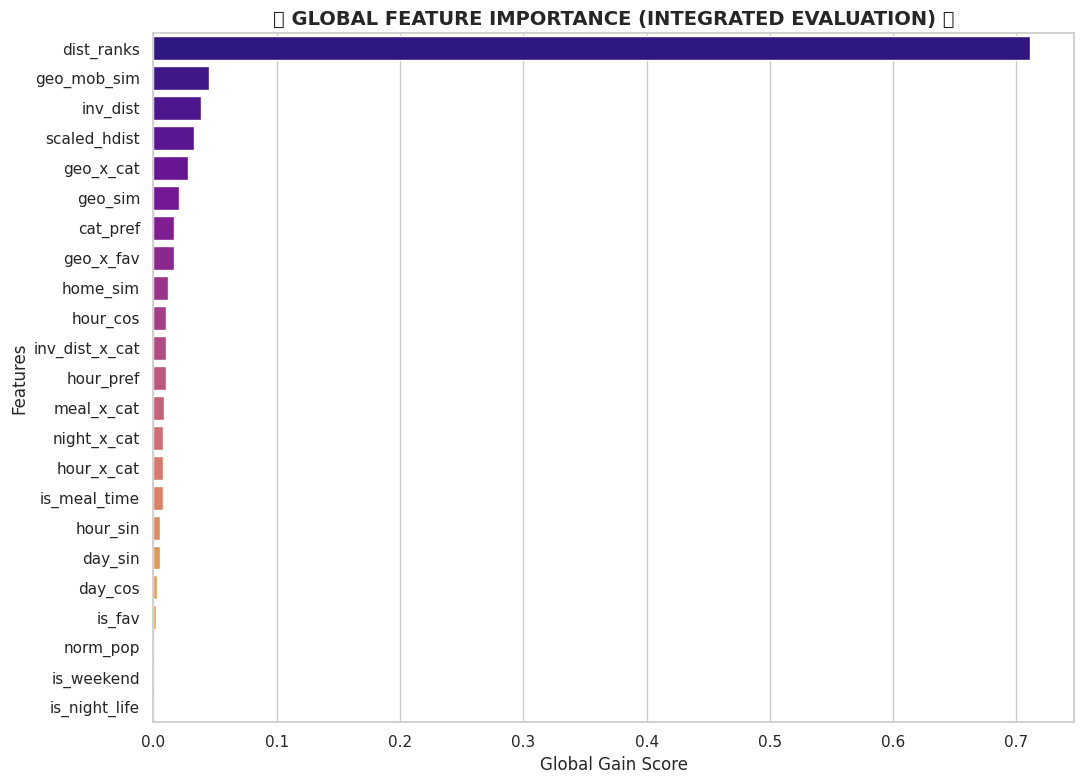


🔥 TOP 10 ĐẶC TRƯNG QUYẾT ĐỊNH ĐIỂM RANKING:
     Feature  Importance
  dist_ranks    0.711090
 geo_mob_sim    0.044822
    inv_dist    0.038707
scaled_hdist    0.032545
   geo_x_cat    0.027735
     geo_sim    0.020921
    cat_pref    0.016761
   geo_x_fav    0.016338
    home_sim    0.011958
    hour_cos    0.010372


In [78]:
# =====================================================================
# LUỒNG CHẠY ĐÁNH GIÁ & VẼ FEATURE IMPORTANCE TOÀN CỤC
# =====================================================================

# 1. Đảm bảo khởi tạo Index không gian dùng chung một lần duy nhất
# (Nhớ đổi chữ 'df' thành tên biến DataFrame chính xác của ông nếu nó mang tên khác)
spatial_tree, places_df = build_spatial_index_by_coord(df_raw)

# 2. Gọi hàm tích hợp: Vừa tính toán Metrics toàn diện, vừa vẽ Chart Importance
# Mặc định lấy mẫu 50 users để chạy mượt, ông có thể tăng lên 100 hoặc None (chạy hết) tùy cấu hình máy
global_model, feat_imp_df = evaluate_and_plot_global_t1(
    df=df_raw,                       # DataFrame gốc chứa toàn bộ lịch sử check-in
    places_df=places_df,         # Bảng chứa thông tin danh mục địa điểm đã gộp
    spatial_tree=spatial_tree,   # BallTree phục vụ truy vấn không gian nhanh
    sample_users_n=50,           # Số lượng users bốc máy ngẫu nhiên để lấy mẫu đặc trưng
    seed=42                      # Khóa ngẫu nhiên cố định để kết quả các lần chạy đồng nhất
)

# 3. Xem nhanh Top 10 Feature có trọng số tác động mạnh nhất hệ thống dưới dạng bảng
print("\n🔥 TOP 10 ĐẶC TRƯNG QUYẾT ĐỊNH ĐIỂM RANKING:")
print(feat_imp_df.head(10).to_string(index=False))

### Đánh giá cá nhân

In [79]:
# =====================================================================
# HÀM ĐÁNH GIÁ METRICS CÁ NHÂN TÁCH BIỆT (INDIVIDUAL METRICS EVALUATION)
# =====================================================================
def evaluate_feature1_individual(df, places_df, spatial_tree):
    """Hàm nhập User ID trực tiếp, tự train mô hình cô lập và trả về Metrics trên tập 20%

    Test.
    """
    default = df["userId"].value_counts().index[0]
    try:
        inp = input(
            f"\n📊 [EVAL INDIVIDUAL] Nhập User ID muốn đánh giá Metrics (Enter={default}): "
        ).strip()
        uid = int(inp) if inp else default
        if uid not in df["userId"].unique():
            raise ValueError("User ID không tồn tại trong Dataset")
    except ValueError as e:
        print(f"  ❌ {e}")
        return None

    # Gọi hàm huấn luyện độc lập cho User đã chọn
    model, profiles, nc = run_feature1_train(df, uid, places_df, spatial_tree)
    if model is None:
        return None

    user_df = (
        df[df["userId"] == uid].sort_values("utcTimestamp").reset_index(drop=True)
    )
    split = int(len(user_df) * 0.8)

    hr1, hr5, mrr_list, all_lbl, all_prb = [], [], [], [], []
    TEST_NEG = 19

    print(
        f"  🧪 Đang chạy tính toán Metrics trên tập Test ({len(user_df) - split} sessions)..."
    )

    # Tiến hành lặp đánh giá trên 20% dữ liệu Test
    for i in range(split, len(user_df)):
        row = user_df.iloc[i]
        prev = user_df.iloc[i - 1]
        u_lat, u_lon = prev["latitude"], prev["longitude"]

        actual = {
            "placeId": row["placeId"],
            "latitude": row["latitude"],
            "longitude": row["longitude"],
            "parent_category": row["parent_category"],
            "popularity": 1,
        }

        _, ind = spatial_tree.query(
            np.radians([[u_lat, u_lon]]), k=min(60, len(places_df))
        )
        near = places_df.iloc[ind[0]].to_dict("records")

        hard = [p for p in near if p["placeId"] != row["placeId"]]
        negs = (
            random.sample(hard, TEST_NEG)
            if len(hard) >= TEST_NEG
            else hard + random.sample(places_df.to_dict("records"), TEST_NEG - len(hard))
        )

        cands = [actual] + negs
        labels = np.array([1] + [0] * len(negs))

        X_step = _build_features_t1(
            u_lat,
            u_lon,
            int(row["hour"]),
            row["hour_sin"],
            row["hour_cos"],
            row["day_sin"],
            row["day_cos"],
            row["is_weekend"],
            uid,
            cands,
            profiles,
            places_df,
        )

        scores = model.predict(X_step)
        all_lbl.extend(labels)
        all_prb.extend(scores)

        rank = np.where(np.argsort(scores)[::-1] == 0)[0][0] + 1
        hr1.append(1 if rank == 1 else 0)
        hr5.append(1 if rank <= 5 else 0)
        mrr_list.append(1.0 / rank)

        if uid in profiles:
            _update_profile_online_t1(profiles[uid], row)

    try:
        auc_str = f"{roc_auc_score(all_lbl, all_prb):.4f}"
    except:
        auc_str = "N/A"

    print(f"\n📈 {'='*15} KẾT QUẢ METRICS CÁ NHÂN CỦA USER #{uid} {'='*15}")
    print(f"  ├─ Hit Rate @ 1 : {np.mean(hr1)*100:.2f}%")
    print(f"  ├─ Hit Rate @ 5 : {np.mean(hr5)*100:.2f}%")
    print(f"  ├─ MRR          : {np.mean(mrr_list):.4f}")
    print(f"  └─ AUC-ROC      : {auc_str}")
    print(f"{'='*65}\n")

    return {
        "User_ID": uid,
        "HR@1": np.mean(hr1),
        "HR@5": np.mean(hr5),
        "MRR": np.mean(mrr_list),
        "AUC": auc_str,
    }

In [80]:
# Khởi tạo index không gian trước
spatial_tree, places_df = build_spatial_index_by_coord(df_raw)

# Gọi hàm đánh giá metrics cá nhân
user_metrics = evaluate_feature1_individual(df_raw, places_df, spatial_tree)


📊 [EVAL INDIVIDUAL] Nhập User ID muốn đánh giá Metrics (Enter=822): 

  🚀 [TÍNH NĂNG 1] HUẤN LUYỆN MÔ HÌNH XGBRANKER CHO USER #822
  ├─ Base train thành công: 16929 samples | Unique sessions (QIDs): 1539
  🧪 Đang chạy tính toán Metrics trên tập Test (385 sessions)...

📈 =============== KẾT QUẢ METRICS CÁ NHÂN CỦA USER #822 ===============
  ├─ Hit Rate @ 1 : 47.53%
  ├─ Hit Rate @ 5 : 68.83%
  ├─ MRR          : 0.5860
  └─ AUC-ROC      : 0.8097



## Tính năng 2

### Đánh giá toàn cục


🌐 [EVAL GLOBAL] BẮT ĐẦU ĐÁNH GIÁ TOÀN CỤC TÍNH NĂNG 2 (50 USERS)
-> Đang quét ngẫu nhiên qua các session mẫu...

👑 =============== BÁO CÁO KẾT QUẢ ĐÁNH GIÁ TOÀN CỤC TÍNH NĂNG 2 ===============
  ├─ Tổng số mẫu User chạy thành công: 50/50
  ├─ Mean AUC-ROC  : 0.7793
  ├─ Mean Precision: 0.5097
  ├─ Mean Recall   : 0.6602
  └─ Mean F1-Score : 0.5635



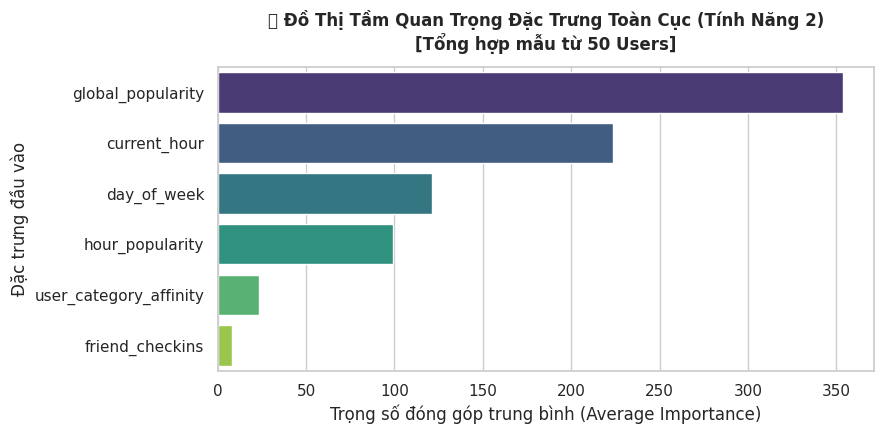

In [81]:
# =====================================================================
# 🔥 CHỨC NĂNG CHÍNH 3: HÀM ĐÁNH GIÁ TOÀN CỤC (RANDOM 50 USERS + GLOBAL GRAPH)
# =====================================================================
def evaluate_feature2_global(df, places_df, spatial_tree, sample_users_n=50, seed=42):
    """Bốc ngẫu nhiên N người dùng, tính trung bình phân phối sai số toàn hệ thống,

    vẽ biểu đồ tầm quan trọng đặc trưng chung tổng thể.
    """
    print(
        f"\n{'='*65}\n🌐 [EVAL GLOBAL] BẮT ĐẦU ĐÁNH GIÁ TOÀN CỤC TÍNH NĂNG 2 ({sample_users_n} USERS)\n{'='*65}"
    )

    all_users = df["userId"].unique()
    random.seed(seed)
    sampled_users = random.sample(list(all_users), min(sample_users_n, len(all_users)))

    global_auc, global_precision, global_recall, global_f1 = [], [], [], []
    global_importances = np.zeros(len(T2_FEATURE_COLS))
    valid_eval_count = 0

    print(f"-> Đang quét ngẫu nhiên qua các session mẫu...")

    for idx, uid in enumerate(sampled_users):
        res = run_feature2_train(uid, df, places_df, spatial_tree)
        if res[0] is None:
            continue  # Bỏ qua user lỗi dữ liệu thưa

        model, test_data, _ = res
        X_te, y_te = test_data["X_te"], test_data["y_te"]

        y_pred = model.predict(X_te)
        y_probs = model.predict_proba(X_te)[:, 1]

        try:
            auc = roc_auc_score(y_te, y_probs)
            global_auc.append(auc)
        except:
            continue

        global_precision.append(precision_score(y_te, y_pred, zero_division=0))
        global_recall.append(recall_score(y_te, y_pred, zero_division=0))
        global_f1.append(f1_score(y_te, y_pred, zero_division=0))

        # Tích lũy Feature Importance toàn cục
        global_importances += model.feature_importances_
        valid_eval_count += 1

    if valid_eval_count == 0:
        print("❌ Không có User nào đủ điều kiện trích xuất bộ mẫu thử nghiệm.")
        return None

    # Chia trung bình trọng số Feature Importance toàn hệ thống
    mean_importances = global_importances / valid_eval_count

    print(f"\n👑 {'='*15} BÁO CÁO KẾT QUẢ ĐÁNH GIÁ TOÀN CỤC TÍNH NĂNG 2 {'='*15}")
    print(f"  ├─ Tổng số mẫu User chạy thành công: {valid_eval_count}/{sample_users_n}")
    print(f"  ├─ Mean AUC-ROC  : {np.mean(global_auc):.4f}")
    print(f"  ├─ Mean Precision: {np.mean(global_precision):.4f}")
    print(f"  ├─ Mean Recall   : {np.mean(global_recall):.4f}")
    print(f"  └─ Mean F1-Score : {np.mean(global_f1):.4f}")
    print(f"{'='*75}\n")

    # Khởi tạo vẽ biểu đồ Feature Importance Toàn Cục (Global Graph)
    global_fi_df = pd.DataFrame(
        {"Feature": T2_FEATURE_COLS, "Global_Importance": mean_importances}
    ).sort_values("Global_Importance", ascending=False)

    plt.figure(figsize=(9, 4.5))
    sns.barplot(
        x="Global_Importance", y="Feature", data=global_fi_df, palette="viridis"
    )
    plt.title(
        f"📊 Đồ Thị Tầm Quan Trọng Đặc Trưng Toàn Cục (Tính Năng 2)\n[Tổng hợp mẫu từ {valid_eval_count} Users]",
        fontweight="bold",
        pad=12,
    )
    plt.xlabel("Trọng số đóng góp trung bình (Average Importance)")
    plt.ylabel("Đặc trưng đầu vào")
    plt.tight_layout()
    plt.show()

    return global_fi_df

spatial_tree, places_df = build_spatial_index_by_place(df_raw)
global_importance_table = evaluate_feature2_global(df_raw, places_df, spatial_tree, sample_users_n=50)


### Đánh giá cá nhân


📊 [EVAL INDIVIDUAL] Nhập User ID muốn đánh giá Metrics (Enter=822): 

🔄 Đang trích xuất đặc trưng và tính toán cho riêng User #822...

📈 =============== METRICS PHÂN LOẠI CÁ NHÂN: USER #822 ===============
  ├─ AUC-ROC  : 0.9287  ✅
  ├─ Precision: 0.8098
  ├─ Recall   : 0.7299
  ├─ F1-Score : 0.7678
  └─ Tập Train/Test: 6156 / 1540 mẫu



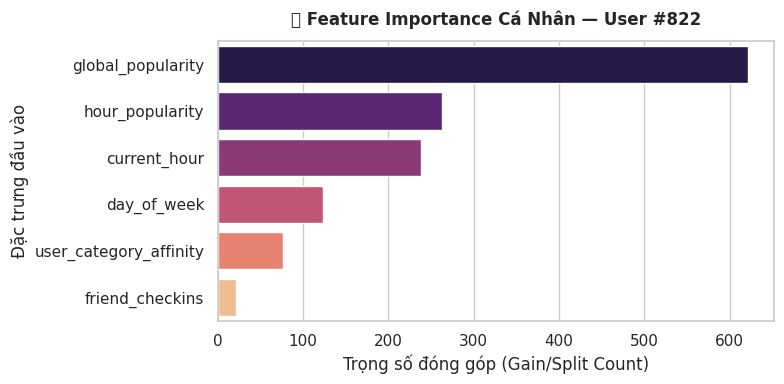

In [82]:
def evaluate_feature2_individual(df, places_df, spatial_tree):
    """Nhập User ID -> Tính toán chi tiết hệ số phân loại -> Vẽ Feature Importance riêng."""
    default = df["userId"].value_counts().index[0]
    try:
        inp = input(
            f"\n📊 [EVAL INDIVIDUAL] Nhập User ID muốn đánh giá Metrics (Enter={default}): "
        ).strip()
        uid = int(inp) if inp else default
        if uid not in df["userId"].unique():
            raise ValueError("User ID không tồn tại.")
    except ValueError as e:
        print(f"  ❌ {e}")
        return None

    print(f"\n🔄 Đang trích xuất đặc trưng và tính toán cho riêng User #{uid}...")
    model, test_data, tr_ds = run_feature2_train(uid, df, places_df, spatial_tree)

    if model is None:
        print(f"  ❌ Dữ liệu User #{uid} không đủ chuẩn (quá ít check-in/bạn bè).")
        return None

    X_te, y_te = test_data["X_te"], test_data["y_te"]
    y_pred = model.predict(X_te)
    y_probs = model.predict_proba(X_te)[:, 1]

    print(f"\n📈 {'='*15} METRICS PHÂN LOẠI CÁ NHÂN: USER #{uid} {'='*15}")
    try:
        auc = roc_auc_score(y_te, y_probs)
        print(f"  ├─ AUC-ROC  : {auc:.4f}  {'⚠️ nghi leakage' if auc > 0.95 else '✅'}")
    except:
        auc = 0.5
        print("  ├─ AUC-ROC  : N/A")

    p_score = precision_score(y_te, y_pred, zero_division=0)
    r_score = recall_score(y_te, y_pred, zero_division=0)
    f1 = f1_score(y_te, y_pred, zero_division=0)

    print(f"  ├─ Precision: {p_score:.4f}")
    print(f"  ├─ Recall   : {r_score:.4f}")
    print(f"  ├─ F1-Score : {f1:.4f}")
    print(f"  └─ Tập Train/Test: {len(tr_ds)} / {len(X_te)} mẫu")
    print(f"{'='*65}\n")

    # Vẽ đồ thị tầm quan trọng đặc trưng riêng lẻ
    fi_df = pd.DataFrame(
        {"Feature": T2_FEATURE_COLS, "Importance": model.feature_importances_}
    ).sort_values("Importance", ascending=False)

    plt.figure(figsize=(8, 4))
    sns.barplot(x="Importance", y="Feature", data=fi_df, palette="magma")
    plt.title(
        f"🎯 Feature Importance Cá Nhân — User #{uid}", fontweight="bold", pad=12
    )
    plt.xlabel("Trọng số đóng góp (Gain/Split Count)")
    plt.ylabel("Đặc trưng đầu vào")
    plt.tight_layout()
    plt.show()

    return {"AUC": auc, "Precision": p_score, "Recall": r_score, "F1": f1}

spatial_tree, places_df = build_spatial_index_by_place(df_raw)
individual_metrics = evaluate_feature2_individual(df_raw, places_df, spatial_tree)

## Tính năng 3

### Đánh giá toàn cục


🌐 [EVAL GLOBAL T3] ĐÁNH GIÁ RANKING TOÀN CỤC TÍNH NĂNG 3 (50 USERS)
-> Phát hiện cột 'cluster' trong dataset. Đang ánh xạ nhãn phân cụm của Users...
-> Không thấy biến 'pm' truyền vào. Tự động xây dựng Profile Matrix từ Train Split...
-> Đang huấn luyện mô hình nền tảng trên tập Train nội bộ (157,720 check-ins)...
-> Đang quét và tính toán Metrics trên 50 users ngẫu nhiên...

👑 ============ BÁO CÁO ĐÁNH GIÁ CHỈ SỐ TOÀN CỤC TÍNH NĂNG 3 ============
  ├─ Số lượng Users test thực tế  : 21/50
  ├─ Mean Precision@5             : 43.81%
  ├─ Mean Recall@5                : 87.11%
  ├─ Mean NDCG@5 (Binary chuẩn)   : 0.9027
  └─ Mean MRR (Vị trí đầu trúng)  : 0.8810



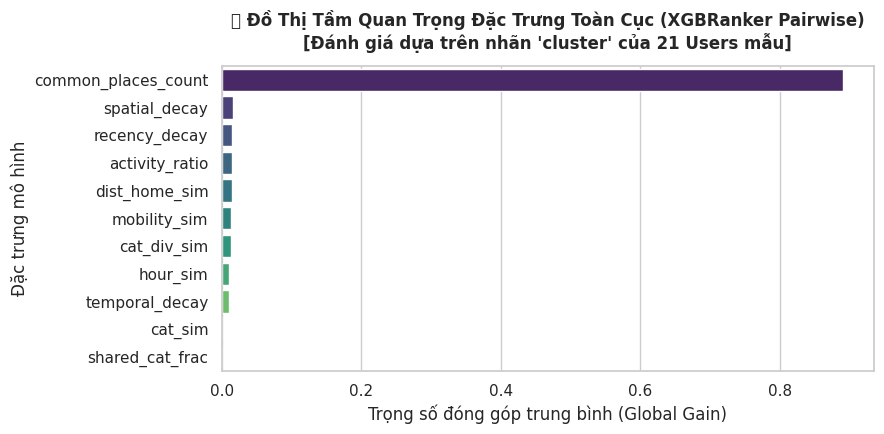

In [83]:
def evaluate_feature3_global(df, pm=None, sample_users_n=50, seed=99):
    """
    Đánh giá toàn cục Tính năng 3: Tự động trích xuất nhãn từ cột 'cluster' trong dataset,
    tự động chia Train/Test và cấu trúc Profile Matrix nếu bị thiếu (pm=None).
    """
    print(f"\n{'='*70}\n🌐 [EVAL GLOBAL T3] ĐÁNH GIÁ RANKING TOÀN CỤC TÍNH NĂNG 3 ({sample_users_n} USERS)\n{'='*70}")

    # 1. Tự động trích xuất nhãn cụm từ cột 'cluster' có sẵn trong dataset của ông
    if 'cluster' in df.columns:
        print("-> Phát hiện cột 'cluster' trong dataset. Đang ánh xạ nhãn phân cụm của Users...")
        # Lấy bản ghi cuối cùng hoặc duy nhất của mỗi user để biết họ thuộc cluster nào
        user_cluster_map = df.groupby('userId')['cluster'].last().to_dict()
    else:
        print("-> ⚠️ Không tìm thấy cột 'cluster' trong DF. Tự động gom tất cả user vào cùng cụm 0...")
        user_cluster_map = {uid: 0 for uid in df['userId'].unique()}

    # 2. Tự động chia Train/Test theo tiến trình thời gian
    df_sorted = df.sort_values('utcTimestamp').reset_index(drop=True)
    split_idx = int(len(df_sorted) * 0.8)
    internal_train_df = df_sorted.iloc[:split_idx].copy()
    internal_test_df  = df_sorted.iloc[split_idx:].copy()

    # 3. Xử lý bọc giáp cho biến 'pm' (Profile Matrix)
    if pm is None:
        print("-> Không thấy biến 'pm' truyền vào. Tự động xây dựng Profile Matrix từ Train Split...")
        pm_pivot = internal_train_df.pivot_table(
            index='userId',
            columns='parent_category',
            values='simulated_rating',
            aggfunc='mean'
        ).fillna(0.0)
        pm_dict = {uid: pm_pivot.loc[uid].values.astype(float) for uid in pm_pivot.index}
        pm_backup_df = pm_pivot
    else:
        pm_dict = _precompute_pm_dict_t3(pm)
        pm_backup_df = pm

    print(f"-> Đang huấn luyện mô hình nền tảng trên tập Train nội bộ ({len(internal_train_df):,} check-ins)...")
    ranker = _train_ranker_t3(internal_train_df, pm_backup_df, user_cluster_map)
    if ranker is None:
        print("  ❌ Không thể khởi tạo mô hình do dữ liệu không đủ cặp ứng viên.")
        return None

    rng = np.random.default_rng(seed)
    all_uids = list(internal_test_df['userId'].unique())

    max_cats   = internal_train_df['parent_category'].nunique()
    max_ts     = internal_train_df['utcTimestamp'].max()
    user_stats = _precompute_user_stats_t3(internal_train_df)
    place_cat_idx = _build_place_cat_index_t3(internal_train_df)

    # Lấy snapshot check-in cuối cùng từ tập Test để mô phỏng real-time
    last_snaps_d = (internal_test_df.sort_values('utcTimestamp')
                                    .groupby('userId').last()
                                    .to_dict(orient='index'))

    sampled_users = rng.choice(all_uids, size=min(sample_users_n, len(all_uids)), replace=False)

    prec_list, rec_list, ndcg_list, mrr_list = [], [], [], []
    valid_count = 0

    print(f"-> Đang quét và tính toán Metrics trên {sample_users_n} users ngẫu nhiên...")
    for target in sampled_users:
        if target not in last_snaps_d: continue
        t_snap = last_snaps_d[target]
        t_clus = user_cluster_map.get(target, -1)

        # Lọc ứng viên: Cùng cluster trích xuất từ dataset + Thỏa mãn snapshot
        cands = [u for u in all_uids
                 if u != target and user_cluster_map.get(u, -2) == t_clus
                 and u in last_snaps_d]
        if not cands: continue

        rows = []
        for c in cands:
            feat = _build_features_t3(target, c, t_snap, last_snaps_d[c],
                                      pm_dict, place_cat_idx, user_stats, max_cats, max_ts)
            if feat is not None:
                feat['userId'] = c
                rows.append(feat)

        cdf = pd.DataFrame(rows)
        if cdf.empty or cdf['label'].sum() == 0: continue

        cdf['score'] = ranker.predict(cdf[T3_FEATURE_COLS])
        top = cdf.nlargest(5, 'score')

        p, r, ndcg, mrr = _ranking_metrics_t3(top['label'].tolist(), cdf['label'].tolist(), top_k=5)
        prec_list.append(p)
        rec_list.append(r)
        ndcg_list.append(ndcg)
        mrr_list.append(mrr)
        valid_count += 1

    if valid_count == 0:
        print("❌ Không tìm được tập mẫu thử nghiệm nào thỏa mãn điều kiện lọc khắt khe (<10km & <72h VÀ có nhãn bạn bè).")
        return None

    print(f"\n👑 {'='*12} BÁO CÁO ĐÁNH GIÁ CHỈ SỐ TOÀN CỤC TÍNH NĂNG 3 {'='*12}")
    print(f"  ├─ Số lượng Users test thực tế  : {valid_count}/{sample_users_n}")
    print(f"  ├─ Mean Precision@5             : {np.mean(prec_list)*100:.2f}%")
    print(f"  ├─ Mean Recall@5                : {np.mean(rec_list)*100:.2f}%")
    print(f"  ├─ Mean NDCG@5 (Binary chuẩn)   : {np.mean(ndcg_list):.4f}")
    print(f"  └─ Mean MRR (Vị trí đầu trúng)  : {np.mean(mrr_list):.4f}")
    print(f"{'='*70}\n")

    # Vẽ đồ thị Feature Importance toàn cục tổng kết từ XGBRanker
    global_fi_df = pd.DataFrame({
        'Feature': T3_FEATURE_COLS,
        'Global_Importance': ranker.feature_importances_
    }).sort_values('Global_Importance', ascending=False)

    plt.figure(figsize=(9, 4.5))
    sns.barplot(x='Global_Importance', y='Feature', data=global_fi_df, palette='viridis')
    plt.title(f"📊 Đồ Thị Tầm Quan Trọng Đặc Trưng Toàn Cục (XGBRanker Pairwise)\n[Đánh giá dựa trên nhãn 'cluster' của {valid_count} Users mẫu]", fontweight='bold', pad=12)
    plt.xlabel("Trọng số đóng góp trung bình (Global Gain)")
    plt.ylabel("Đặc trưng mô hình")
    plt.tight_layout()
    plt.show()

    return global_fi_df

global_importance_t3 = evaluate_feature3_global(df_raw, sample_users_n=50)

### Đánh giá cá nhân


🔄 Đang tối ưu hóa cấu trúc dữ liệu và phân tách tập dữ liệu Test...
-> Không thấy biến 'pm' truyền vào. Tự động xây dựng Profile Matrix từ Train Split...
🔄 Khởi tạo mô hình xếp hạng XGBRanker trên tập huấn luyện nội bộ...

📊 [EVAL T3 INDIVIDUAL] Nhập User ID cần kiểm tra Metrics Ranking (Enter=822): 

📈 ============ KẾT QUẢ ĐÁNH GIÁ RANKING USER #822 ============
  ├─ Precision@5 : 80.00%
  ├─ Recall@5    : 57.14%
  ├─ NDCG@5      : 0.7860
  └─ MRR         : 1.0000



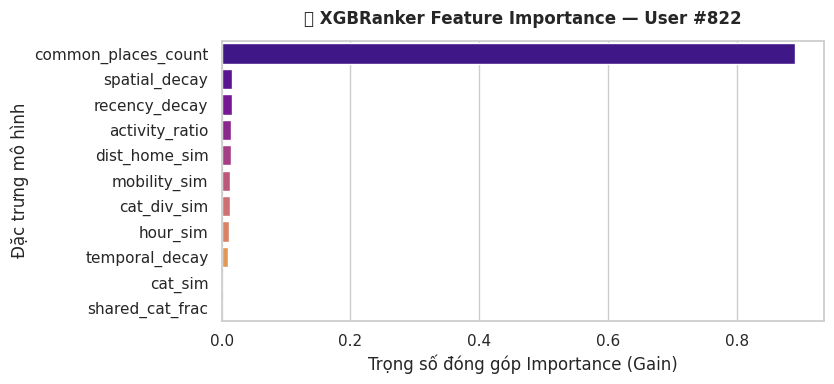

In [84]:
def evaluate_feature3_individual(df, pm=None, seed=42):
    """
    Đánh giá chi tiết Ranking cá nhân: Tự động trích xuất nhãn từ cột 'cluster' trong dataset,
    tự động tách Train/Test 80/20 theo thời gian và tự dựng Profile Matrix nếu thiếu (pm=None).
    """
    print("\n🔄 Đang tối ưu hóa cấu trúc dữ liệu và phân tách tập dữ liệu Test...")

    # 1. Tự động trích xuất nhãn cụm từ cột 'cluster' có sẵn trong dataset của ông
    if 'cluster' in df.columns:
        user_cluster_map = df.groupby('userId')['cluster'].last().to_dict()
    else:
        print("-> ⚠️ Không tìm thấy cột 'cluster' trong DF. Tự động gom tất cả user vào cùng cụm 0...")
        user_cluster_map = {uid: 0 for uid in df['userId'].unique()}

    # 2. Tự động chia Train/Test theo tiến trình thời gian giống hệt hàm Global
    df_sorted = df.sort_values('utcTimestamp').reset_index(drop=True)
    split_idx = int(len(df_sorted) * 0.8)
    internal_train_df = df_sorted.iloc[:split_idx].copy()
    internal_test_df  = df_sorted.iloc[split_idx:].copy()

    # 3. Xử lý bọc giáp cho biến 'pm' (Profile Matrix)
    if pm is None:
        print("-> Không thấy biến 'pm' truyền vào. Tự động xây dựng Profile Matrix từ Train Split...")
        pm_pivot = internal_train_df.pivot_table(
            index='userId',
            columns='parent_category',
            values='simulated_rating',
            aggfunc='mean'
        ).fillna(0.0)
        pm_dict = {uid: pm_pivot.loc[uid].values.astype(float) for uid in pm_pivot.index}
        pm_backup_df = pm_pivot
    else:
        pm_dict = _precompute_pm_dict_t3(pm)
        pm_backup_df = pm

    print("🔄 Khởi tạo mô hình xếp hạng XGBRanker trên tập huấn luyện nội bộ...")
    ranker = _train_ranker_t3(internal_train_df, pm_backup_df, user_cluster_map)
    if ranker is None:
        print("  ❌ Không đủ cặp dữ liệu chuẩn để huấn luyện mô hình.")
        return None

    # Lấy User ID mặc định có nhiều tương tác nhất trong tập Test để gợi ý cho User đỡ phải gõ
    default = internal_test_df["userId"].value_counts().index[0]
    try:
        inp = input(
            f"\n📊 [EVAL T3 INDIVIDUAL] Nhập User ID cần kiểm tra Metrics Ranking (Enter={default}): "
        ).strip()
        uid = int(inp) if inp else default
        if uid not in internal_test_df["userId"].unique():
            raise ValueError("Người dùng này không xuất hiện trong tập Test Split (20% dữ liệu cuối).")
    except ValueError as e:
        print(f"  ❌ {e}")
        return None

    max_cats   = internal_train_df["parent_category"].nunique()
    max_ts     = internal_train_df["utcTimestamp"].max()
    user_stats = _precompute_user_stats_t3(internal_train_df)
    place_cat_idx = _build_place_cat_index_t3(internal_train_df)

    # Trích xuất snapshot cuối cùng trong tập Test
    last_snaps_d = (
        internal_test_df.sort_values("utcTimestamp")
        .groupby("userId")
        .last()
        .to_dict(orient="index")
    )

    if uid not in last_snaps_d:
        print(f"  ❌ Không tìm thấy snapshot vị trí tập test của User #{uid}")
        return None

    t_snap = last_snaps_d[uid]
    t_clus = user_cluster_map.get(uid, -1)
    all_uids = list(internal_test_df["userId"].unique())

    # Lọc ứng viên dựa trên map cluster đã trích xuất tự động
    cands = [
        u for u in all_uids
        if u != uid
        and user_cluster_map.get(u, -2) == t_clus
        and u in last_snaps_d
    ]
    if not cands:
        print(f"  ❌ Không có ứng viên cùng nhóm hành vi trong tập Test.")
        return None

    rows = []
    for c in cands:
        feat = _build_features_t3(
            uid, c, t_snap, last_snaps_d[c],
            pm_dict, place_cat_idx, user_stats, max_cats, max_ts,
        )
        if feat is not None:
            feat["userId"] = c
            rows.append(feat)

    cdf = pd.DataFrame(rows)
    if cdf.empty or cdf["label"].sum() == 0:
        print(f"  ⚠️  User #{uid} không có bất kì nhãn positive (label=1) nào ở tập ứng viên hợp lệ tại tập Test.")
        return None

    cdf["score"] = ranker.predict(cdf[T3_FEATURE_COLS])
    top = cdf.nlargest(5, "score")

    # --- ĐÃ FIX LỖI DẤU NHÁY ĐƠN TRONG STRING LITERAL TẠI ĐÂY ---
    p, r, ndcg, mrr = _ranking_metrics_t3(
        top["label"].tolist(), cdf["label"].tolist(), top_k=5
    )

    print(f"\n📈 {'='*12} KẾT QUẢ ĐÁNH GIÁ RANKING USER #{uid} {'='*12}")
    print(f"  ├─ Precision@5 : {p*100:.2f}%")
    print(f"  ├─ Recall@5    : {r*100:.2f}%")
    print(f"  ├─ NDCG@5      : {ndcg:.4f}")
    print(f"  └─ MRR         : {mrr:.4f}")
    print(f"{'='*60}\n")

    # Trích xuất và vẽ đồ thị Feature Importance từ XGBRanker cấu trúc cây
    importance_scores = ranker.feature_importances_
    fi_df = pd.DataFrame(
        {"Feature": T3_FEATURE_COLS, "Importance": importance_scores}
    ).sort_values("Importance", ascending=False)

    plt.figure(figsize=(8.5, 4))
    sns.barplot(x="Importance", y="Feature", data=fi_df, palette="plasma")
    plt.title(f"🎯 XGBRanker Feature Importance — User #{uid}", fontweight="bold", pad=12)
    plt.xlabel("Trọng số đóng góp Importance (Gain)")
    plt.ylabel("Đặc trưng mô hình")
    plt.tight_layout()
    plt.show()

    return {"Precision@5": p, "Recall@5": r, "NDCG@5": ndcg, "MRR": mrr}

ind_metrics_t3 = evaluate_feature3_individual(df_raw)

# Vận hành

In [85]:
def main_menu(df):
    print("\n" + "="*60)
    print("  🌏 ROAMIO PLATFORM — MENU CHÍNH")
    print("="*60)
    print("  1️⃣  Gợi ý địa điểm theo lịch sử cá nhân   (SGD Online Learning)")
    print("  2️⃣  Gợi ý địa điểm theo cộng đồng cluster (LightGBM Classifier)")
    print("  3️⃣  Gợi ý kết nối bạn bè                  (LightGBM LambdaRank)")
    print("  0️⃣  Thoát")
    print("="*60)
    while True:
        try: choice = input("\n👉 Chọn tính năng (0-3): ").strip()
        except EOFError: break
        if   choice == '1': run_feature1(df)
        elif choice == '2': run_feature2(df)
        elif choice == '3': run_feature3(df)
        elif choice == '0': print("  👋 Tạm biệt!"); break
        else: print("  ⚠️  Vui lòng chọn 0, 1, 2 hoặc 3.")


# ── Chạy toàn bộ hệ thống ─────────────────────────────────────────────────────
main_menu(df_raw)


  🌏 ROAMIO PLATFORM — MENU CHÍNH
  1️⃣  Gợi ý địa điểm theo lịch sử cá nhân   (SGD Online Learning)
  2️⃣  Gợi ý địa điểm theo cộng đồng cluster (LightGBM Classifier)
  3️⃣  Gợi ý kết nối bạn bè                  (LightGBM LambdaRank)
  0️⃣  Thoát

👉 Chọn tính năng (0-3): 1

👤 [TN1] Nhập User ID (Enter=822): 

  🚀 [TÍNH NĂNG 1] HUẤN LUYỆN MÔ HÌNH XGBRANKER CHO USER #822
  ├─ Base train thành công: 16929 samples | Unique sessions (QIDs): 1539

  📍 [TÍNH NĂNG 1] GỢI Ý ĐỊA ĐIỂM CÁ NHÂN
  Vĩ độ   (Enter=35.5528): 35.55
  Kinh độ (Enter=139.7333): 139.73
  Giờ 0-23  (Enter=12): 18
  Thứ 0=T2…6=CN (Enter=0): 1

  🔥 TOP 5 GỢI Ý CHO USER 822 (Thứ 3, 18h):

          Danh mục         Loại hình      Lat       Lon  Khoảng cách (km)
burger/pizza shops Convenience Store 35.55135 139.73112              0.18
             malls              Mall 35.55154 139.72959              0.17
             malls  Department Store 35.55100 139.73287              0.28
burger/pizza shops Convenience Store 35.55277 1